In [95]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sy
import pandas as pd
from scipy.optimize import minimize

# Introduction to Linear Regression and Linear Programming

**OBJECTIVES**

- Derive ordinary least squares models for data
- Evaluate regression models using mean squared error
- Examine errors and assumptions in least squares models
- Use `scikit-learn` to fit regression models to data
- Set up linear programming problems with constraints using `scipy.optimize`

## Calculus Refresher

An important idea is that of finding a maximum or minimum of a function.  From calculus, we have the tools required.  Specifically, a maximum or minimum value of a function $f$ occurs wherever $f'(x) = 0$ or is underfined.  Consider the function:

$$f(x) = x^2$$

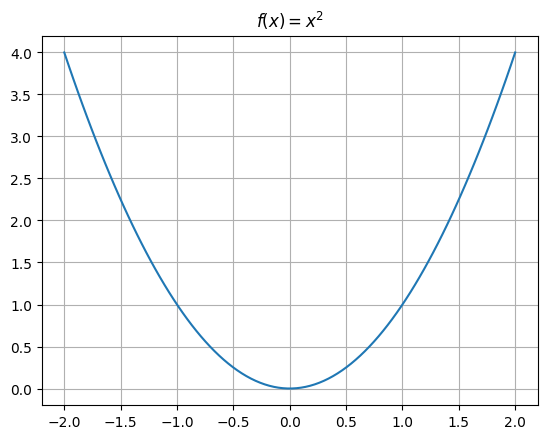

In [96]:
def f(x): return x**2
x = np.linspace(-2, 2, 100)
plt.plot(x, f(x))
plt.grid()
plt.title(r'$f(x) = x^2$');

Here, using our power rule for derivatives of polynomials we have:

$$f'(x) = 2x$$

and are left to solve:

$$0 = 2x$$

or 

$$x = 0$$

**PROBLEM**: Use `minimize` to determine where the function $f(x) = (5 - 2x)^2$ has a minimum.

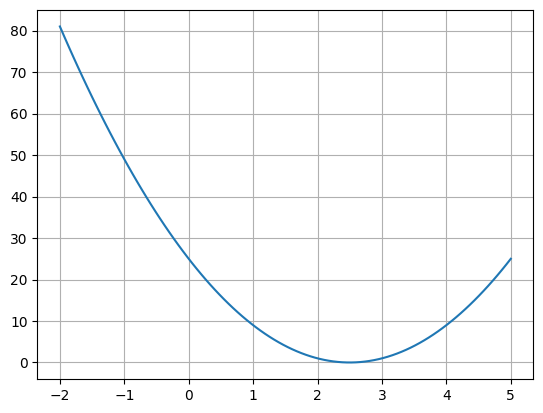

In [97]:
def f(x): return (5 - 2*x)**2
x = np.linspace(-2, 5, 100)
plt.plot(x, f(x))
plt.grid();

In [98]:
# minimize?

In [99]:
x0 = 0
# results = minimize()
# print(results.x)

#### Using the chain rule

**Example 1**: Line of best fit

In [100]:
import seaborn as sns

In [101]:
tips = sns.load_dataset('tips')

In [102]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


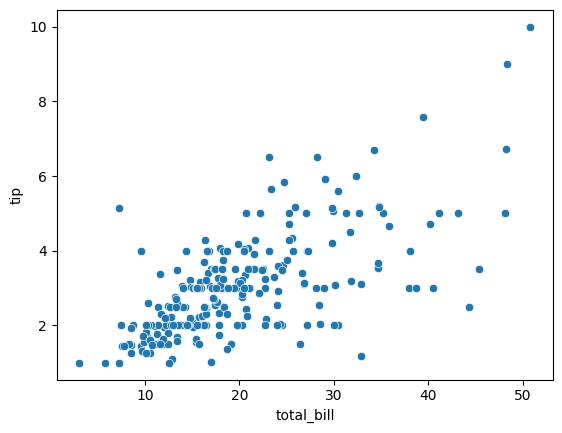

In [103]:
sns.scatterplot(data = tips, x = 'total_bill', y = 'tip');

In [104]:
def y1(x): return .19*x

In [105]:
def y2(x): return .12*x

In [106]:
x = tips['total_bill']

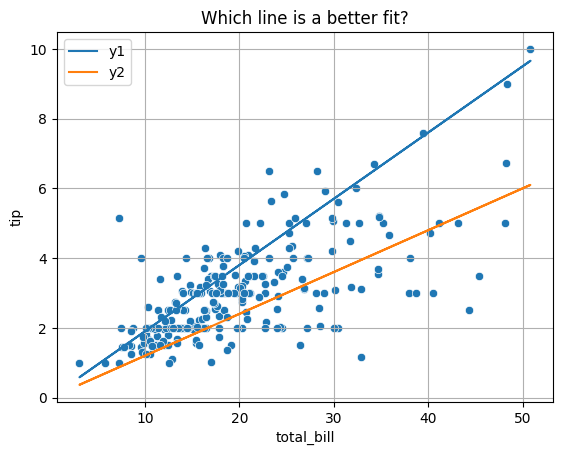

In [107]:
plt.plot(x, y1(x), label = 'y1')
plt.plot(x, y2(x), label = 'y2')
plt.legend()
sns.scatterplot(data = tips, x = 'total_bill', y = 'tip')
plt.title('Which line is a better fit?')
plt.grid();

To decide between all possible lines we will examine the error in all these models and select the one that minimizes this error.

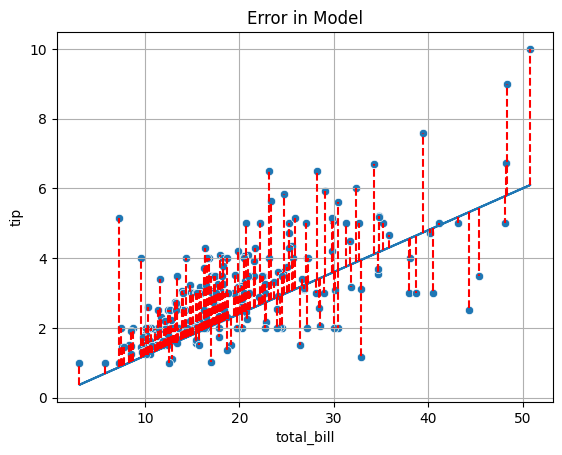

In [108]:
plt.plot(x, y2(x))
for i, yhat in enumerate(y2(x)):
    plt.vlines(x = tips['total_bill'].iloc[i], ymin = yhat, ymax = tips['tip'].iloc[i], color = 'red', linestyle = '--')
sns.scatterplot(data = tips, x = 'total_bill', y = 'tip')
plt.title('Error in Model')
plt.grid();

#### Mean Squared Error

$$\text{MSE}(\beta_0) = \frac{1}{n}\sum_{i = 1}^n (y_i - \beta_0x)^2$$



**OBJECTIVE**: Minimize mean squared error

In [109]:
def mse(beta):
    return np.mean((y - beta*x)**2)

In [110]:
x = tips['total_bill']
y = tips['tip']

In [111]:
mse(.19)

2.185143996844262

In [112]:
mse(.12)

1.4430533029508197

**PROBLEM**

Use the array of slopes below to loop over each possible slope and determine which gives the lowest Mean Squared Error.

In [113]:
slopes = np.linspace(.1, .2, 11)
    

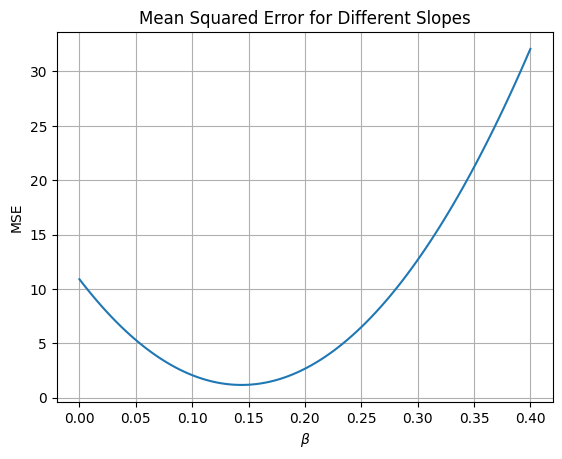

In [114]:
betas = np.linspace(0, .4, 100)
plt.plot(betas, [mse(beta) for beta in betas])
plt.xlabel(r'$\beta$')
plt.ylabel('MSE')
plt.title('Mean Squared Error for Different Slopes')
plt.grid();

#### Using `scipy` 

To find the minimum of our objective function, the `minimize` function can again be used.  It requires a function to be minimized and an intial guess.

### Solving the Problem Exactly

From calculus we know that the minimum value for a quadratic will occur where the first derivative equals zero.  Thus, to determine the equations for the line of best fit, we minimize the MSE function with respect to $\beta$.

$$f(\beta) = \frac{1}{n}\sum_{i = 1}^n (y - \beta x)^2$$

$$f'(\beta) = \frac{-2}{n}\sum_{i = 1}^n(y - \beta x) x$$

$$ 0 = \frac{-2}{n}\sum_{i = 1}^n(y - \beta x) x$$

$$0 = \sum_{i = 1}^n(y - \beta x) x$$

$$0 = \sum yx - \sum \beta x^2 $$

$$\sum \beta x^2 = \sum y x$$

$$\beta \sum x^2 = \sum y x$$

$$\beta = \frac{\sum y x}{\sum x^2}$$

In [115]:
np.sum(tips['total_bill']*tips['tip'])/np.sum(tips['total_bill']**2)

0.14373189527721666

### Adding an intercept

Consider the model:

$$y = \beta_0 + \beta_1 x + \epsilon$$

where $\epsilon = N(0, 1)$.

Now, the objective function changes to be a function in 3-Dimensions where the slope and intercept terms are input and mean squared error is the output.

$$\text{MSE}(\beta_0, \beta_1) = \frac{1}{n}\sum_{i = 1}^n (y - (\beta_0 + \beta_1 x)^2)$$

In [116]:
def mse(betas):
    return np.mean((y - (betas[0] + betas[1]*x))**2)

In [117]:
mse([4, 3])

4305.7986356557385

In [118]:
slopes = np.linspace(4, 5, 10)
intercepts = np.linspace(2, 3, 10)
for slope in slopes:
    for intercept in intercepts:
        print(f'Slope {slope: .2f}, Intercept: {intercept: .2f}, MSE: {mse([slope, intercept])}')

Slope  4.00, Intercept:  2.00, MSE: 1930.6791278688527
Slope  4.00, Intercept:  2.11, MSE: 2148.120884836066
Slope  4.00, Intercept:  2.22, MSE: 2377.1777444444447
Slope  4.00, Intercept:  2.33, MSE: 2617.8497066939894
Slope  4.00, Intercept:  2.44, MSE: 2870.1367715846995
Slope  4.00, Intercept:  2.56, MSE: 3134.038939116575
Slope  4.00, Intercept:  2.67, MSE: 3409.556209289617
Slope  4.00, Intercept:  2.78, MSE: 3696.6885821038245
Slope  4.00, Intercept:  2.89, MSE: 3995.436057559198
Slope  4.00, Intercept:  3.00, MSE: 4305.7986356557385
Slope  4.11, Intercept:  2.00, MSE: 1939.7078305606155
Slope  4.11, Intercept:  2.11, MSE: 2157.6381293209874
Slope  4.11, Intercept:  2.22, MSE: 2387.183530722526
Slope  4.11, Intercept:  2.33, MSE: 2628.3440347652295
Slope  4.11, Intercept:  2.44, MSE: 2881.1196414491
Slope  4.11, Intercept:  2.56, MSE: 3145.510350774134
Slope  4.11, Intercept:  2.67, MSE: 3421.516162740336
Slope  4.11, Intercept:  2.78, MSE: 3709.137077347703
Slope  4.11, Intercep

In [119]:
minimize(mse, [5, 3])

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 1.0360194420115216
        x: [ 9.203e-01  1.050e-01]
      nit: 5
      jac: [-5.960e-08 -8.643e-07]
 hess_inv: [[ 2.980e+00 -1.253e-01]
            [-1.253e-01  6.334e-03]]
     nfev: 18
     njev: 6

In [120]:
betas = minimize(mse, [0, 0]).x

In [121]:
def lobf(x): return betas[0] + betas[1]*x

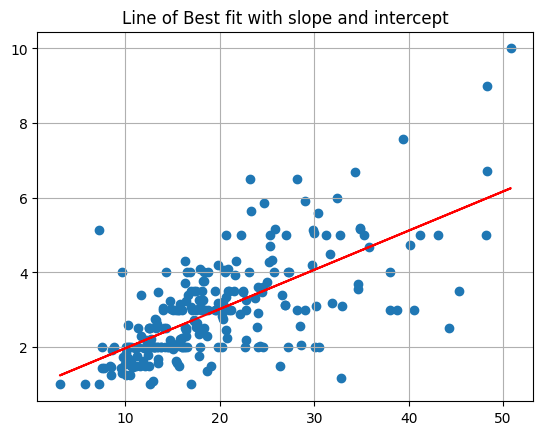

In [122]:
plt.scatter(x, y)
plt.plot(x, lobf(x), color = 'red')
plt.grid()
plt.title('Line of Best fit with slope and intercept');

### Using `scikit-learn`

The `scikit-learn` library has many predictive models and modeling tools.  It is a popular library in industry for Machine Learning tasks. [docs](https://scikit-learn.org/stable/index.html)

In [43]:
# !pip install -U scikit-learn

In [123]:
credit = pd.read_csv('https://raw.githubusercontent.com/jfkoehler/nyu_bootcamp_fa25/refs/heads/main/data/Credit.csv', index_col=0)
credit.head()

,Income,Limit,Rating,Cards,Age,Education,Gender,Student,Married,Ethnicity,Balance
1,14.891,3606,283,2,34,11,Male,No,Yes,Caucasian,333
2,106.025,6645,483,3,82,15,Female,Yes,Yes,Asian,903
3,104.593,7075,514,4,71,11,Male,No,No,Asian,580
4,148.924,9504,681,3,36,11,Female,No,No,Asian,964
5,55.882,4897,357,2,68,16,Male,No,Yes,Caucasian,331


In [45]:
from sklearn.linear_model import LinearRegression

**PROBLEM**: Which feature is the strongest predictor of `Balance` in the data?

<Axes: >

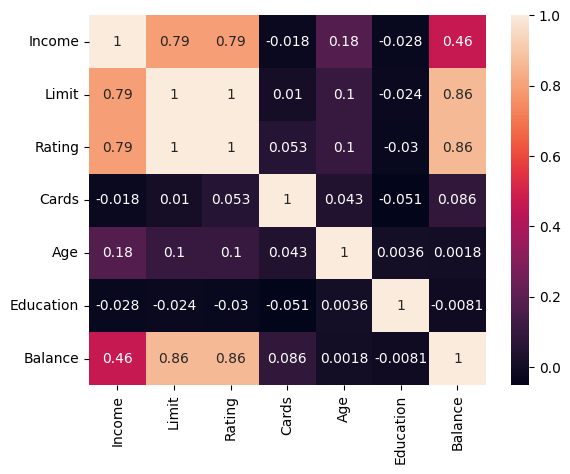

In [46]:
sns.heatmap(credit.corr(numeric_only = True), annot = True)

In [124]:
#define X as the feature most correlated with Balance
#and y as Balance


**PROBLEM**: Build a `LinearRegression` model, determine the **Root Mean Squared Error** and interpret the slope and intercept.

1. Instantiate
2. Fit
3. Predict/score

In [125]:
#instantiate


In [126]:
#fit


In [50]:
#look at coefficient and intercept


The model is y = 2.5662403273433196x + -390.84634178723786


In [127]:
#examine the distribution of errors -- want normal centered at 0


In [53]:
from sklearn.metrics import mean_squared_error

In [128]:
#make predictions


In [129]:
#error between true and predicted


### Problem: Determine $\alpha$ and $\beta$ of an investment

Consider an investment with return of the market as $R_M$ (say the S&P) and the return of a stock $R$ over the same time period.

$$R = \alpha + \beta*R_M + \epsilon$$

In [55]:
import yfinance as yf

In [56]:
data = yf.download(["NVDA", "SPY"], period="5y")
data.head()

Failed to get ticker 'SPY' reason: Expecting value: line 1 column 1 (char 0)
Failed to get ticker 'NVDA' reason: Expecting value: line 1 column 1 (char 0)
[*********************100%***********************]  1 of 2 completed

2 Failed downloads:
['NVDA', 'SPY']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


Empty DataFrame
Columns: [(Adj Close, NVDA), (Adj Close, SPY), (Close, NVDA), (Close, SPY), (High, NVDA), (High, SPY), (Low, NVDA), (Low, SPY), (Open, NVDA), (Open, SPY), (Volume, NVDA), (Volume, SPY)]
Index: []

In [57]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 0 entries
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, NVDA)  0 non-null      float64
 1   (Adj Close, SPY)   0 non-null      float64
 2   (Close, NVDA)      0 non-null      float64
 3   (Close, SPY)       0 non-null      float64
 4   (High, NVDA)       0 non-null      float64
 5   (High, SPY)        0 non-null      float64
 6   (Low, NVDA)        0 non-null      float64
 7   (Low, SPY)         0 non-null      float64
 8   (Open, NVDA)       0 non-null      float64
 9   (Open, SPY)        0 non-null      float64
 10  (Volume, NVDA)     0 non-null      float64
 11  (Volume, SPY)      0 non-null      float64
dtypes: float64(12)
memory usage: 0.0 bytes


[*********************100%***********************]  1 of 2 completed

In [58]:
close = data.iloc[:, [0, 1]]

<Axes: xlabel='Date'>

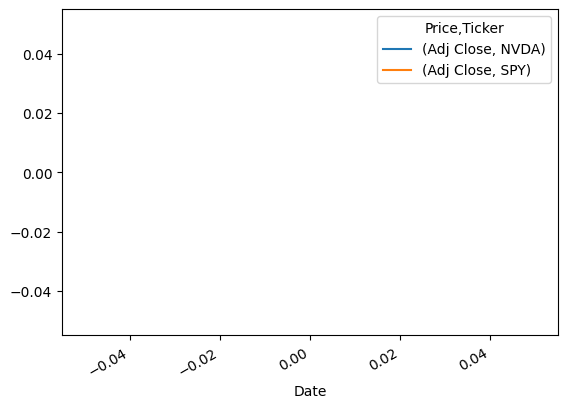

In [59]:
close.pct_change().plot()

In [60]:
returns = close.pct_change()

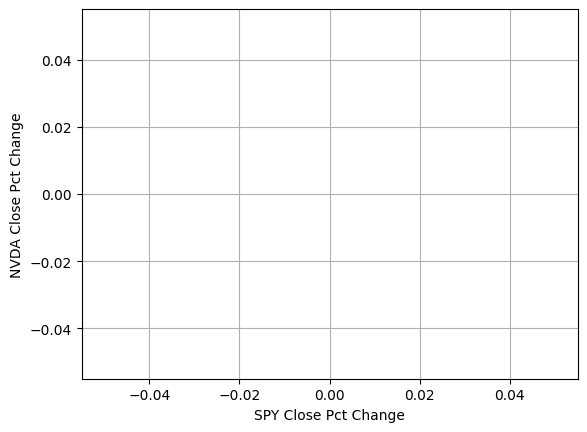

In [61]:
sns.regplot(x = returns.iloc[:, 1], y = returns.iloc[:, 0], scatter_kws={'alpha': 0.3})
plt.xlabel('SPY Close Pct Change')
plt.ylabel('NVDA Close Pct Change')
plt.grid();

In [62]:
#instantiate


In [63]:
#fit


In [64]:
#examine our alpha and beta


#### Problem

Load in the california housing data from the `sample_data` folder in colab.  Use this data to build a regression model with:

1. The most correlated feature to housing prices as input and price as target
2. The five features you believe would be most important
3. Which model has a lower MSE?

### Linear Programming: An example

A dog daycare feeds the dogs a diet that requires a minimum of 15 grams of fiber, 30 grams of protein.  Each pound of chick peas contains 1 gram of protein, 5 grams of fiber, and 25 grams of fat. Cottage cheese contains 2 grams of protein, 1 gram of fiber, and 14 grams of fat. Suppose that chick peas are priced at 8 USD per pound, and cottage cheese at 6 USD per pound.  The nutritionist claims the dogs will not eat more than 285 grams of fat.   Your goal is to obtain the most economical solution given these constraints.

This is summarized in the table below:

| ingredient | protein | fiber | fat | cost |
| ------ | ------ | ------- | ------- | ------- |
| chick peas | 1 g | 5 g | 25 g | \$8 |
| cottage cheese | 2 g | 1 g | 14 g | \$6 |
| minimum | 15 g | 30 g |  |   |
| maximum |    |     |  285 g |   |

Mathematically, the objective function is:

$$C = 6x + 8y$$

where $x$ = chick peas and $y$ = cottage cheese.  This is the total cost of the combination of chick peas and cottage cheese.

We will save the coefficients as a list for use later.

In [69]:
c = [6, 8]

Because each pound of chick peas contains 1 gram of protein and each cottage cheese 2 grams, and know this needs to combine to at least 15 grams you have:

$$2x + y \geq 15$$

As for cottage cheese, you have:

$$x + 5y \geq 30$$

As for the fat content, you have:

$$14x + 25y \leq 285$$

Further, the amount of $x$ and $y$ must not be negative.

#### Graphical representation

To visualize the solution, you can imagine each of the constraints as a region.  First, functions for these are defined and plotted together.  


In [70]:
def cp(x): #chick peas
    return -2*x + 15
def cc(x): #cottage cheese
    return -1/5*x + 30/5
def fat(x): #fat
    return -14/25*x + 285/25
y = 0
x = np.linspace(0, 30, 100)

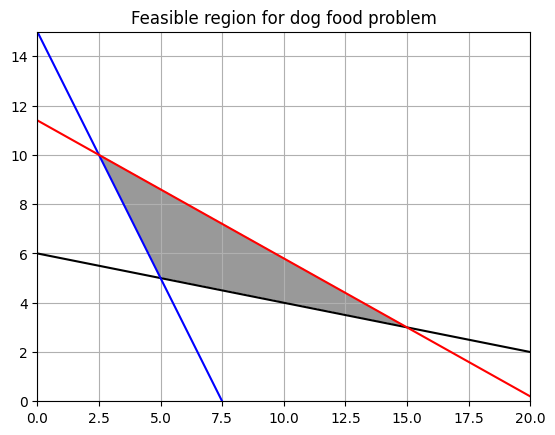

In [71]:
d = np.linspace(0, 30, 1000)
x, y = np.meshgrid(d, d)
plt.imshow((y > cp(x)) & (y < fat(x)) & (y > cc(x)).astype('int'),
           origin = 'lower',
          cmap = 'Greys',
          extent=(x.min(), x.max(), y.min(), y.max()),
          alpha = 0.4)
plt.plot(d, cc(d), '-', color = 'black', label = 'cottage cheese')

plt.plot(d, cp(d), '-', color = 'blue', label = 'chick peas')

plt.plot(d, fat(d), '-', color = 'red', label = 'fat')
plt.ylim(0, 15)
plt.xlim(0, 20)
plt.title('Feasible region for dog food problem')
plt.grid();

The form of all solutions can be found by rewriting the objective function as:

$$y = -\frac{6}{8}x + \frac{C}{8}$$

Below, different values of $C$ are plotted against the original region.  Note that the objective function will obtain its maximum and minimum values at the vertices of the polygon.  Hence, to solve the problem, you need only look to the vertices.  These are highlighted in the plot on the right.

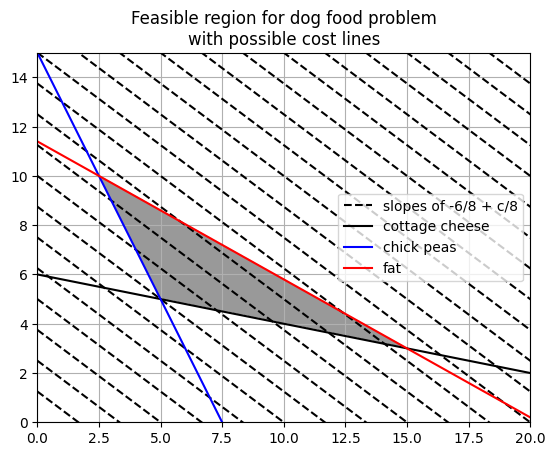

In [72]:
# fig, ax = plt.subplots(1, 2, figsize = (30, 10))
for i in range(10, 1000, 10):
    plt.plot(d, -6/8*d + i/8, '--', color = 'black')
plt.plot(d, -6/8*d + i, '--', color = 'black', label = 'slopes of -6/8 + c/8')
d = np.linspace(0, 30, 1000)
x, y = np.meshgrid(d, d)
plt.imshow((y > cp(x)) & (y < fat(x)) & (y > cc(x)).astype('int'),
           origin = 'lower',
          cmap = 'Greys',
          extent=(x.min(), x.max(), y.min(), y.max()),
          alpha = 0.4)
plt.plot(d, cc(d), '-', color = 'black', label = 'cottage cheese')

plt.plot(d, cp(d), '-', color = 'blue', label = 'chick peas')

plt.plot(d, fat(d), '-', color = 'red', label = 'fat')
plt.ylim(0, 15)
plt.xlim(0, 20)
plt.title('Feasible region for dog food problem\nwith possible cost lines')
plt.grid()
plt.legend();

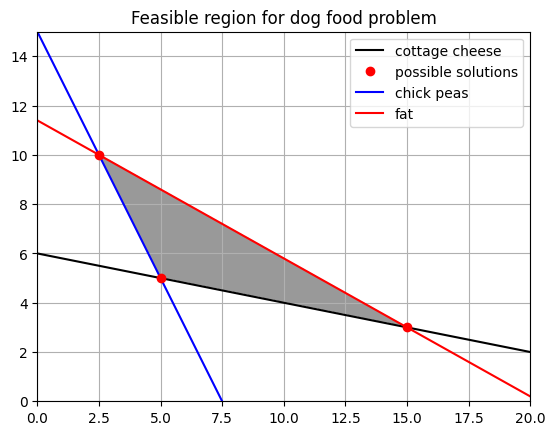

In [73]:
d = np.linspace(0, 30, 1000)
x, y = np.meshgrid(d, d)
plt.imshow((y > cp(x)) & (y < fat(x)) & (y > cc(x)).astype('int'),
           origin = 'lower',
          cmap = 'Greys',
          extent=(x.min(), x.max(), y.min(), y.max()),
          alpha = 0.4)
plt.plot(d, cc(d), '-', color = 'black', label = 'cottage cheese')
plt.plot(15, 3, 'ro', label = 'possible solutions')
plt.plot(d, cp(d), '-', color = 'blue', label = 'chick peas')
plt.plot(d, fat(d), '-', color = 'red', label = 'fat')
plt.ylim(0, 15)
plt.xlim(0, 20)
plt.title('Feasible region for dog food problem')
plt.grid()
plt.plot(5, 5, 'ro')
plt.plot(5/2, 10, 'ro')
plt.legend();

#### using `linprog`

To solve the problem using python, `scipy.optimize` contains the `linprog` function that will solve this problem.  The one exception is that the greater than inequality constraints need to be converted to less thans by multiplying both sides by -1.  

$$C = 6x + 8y$$
$$2x + y \geq 15$$
$$x + 5y \geq 30$$
$$14x + 25y \leq 285$$

In [74]:
#cost coeffients
c = [6, 8]
#coefficients of less than problems
A = [[-2, -1], [-1, -5], [14, 25]]
#right side of inequalities
b = [-15, -30, 285]
res = optim.linprog(c, A, b)

In [75]:
res

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 70.0
              x: [ 5.000e+00  5.000e+00]
            nit: 2
          lower:  residual: [ 5.000e+00  5.000e+00]
                 marginals: [ 0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00  9.000e+01]
                 marginals: [-2.444e+00 -1.111e+00 -0.000e+00]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

**EXAMPLE**

Suppose we have the opportunity to invest in four projects with given cash flows, net present value, and profitability index ($\frac{NPV}{\text{investment}}$) given below.

| PROJECT | $C_0$ | $C_1$ | $C_2$ | NPV at 10% | Profitability Index |
| ------- | ------ | ------- | ------- | -------- | --------- |
| A | -10 | -30 | 5 | 21 | 2.1 |
| B | -5 | 5 | 2 | 16 | 3.2 |
| C | -5 | 5 | 15 | 12 | 2.4 |
| D | 0 | -40 | 60 | 13 | 0.4 |



$$NPV = 21x_A + 16x_B + 12x_C + 13x_D$$

**CONSTRAINTS**

Cash flows for period 0 must not be greater than 10 million.

$$10x_A + 5x_B + 5x_C + 0x_D \leq 10$$

Total outflow in period 1 must not be greater than 10 million.

$$-30x_A - 5x_B - 5x_C + 40x_D \leq 10$$

Finally the amount of the investment must be positive and we cannot purchase more than one of each.

$$0 \leq x_A \leq 1$$
$$0 \leq x_B \leq 1$$
$$0 \leq x_C \leq 1$$
$$0 \leq x_D \leq 1$$

In [76]:
from scipy.optimize import linprog

In [77]:
coefs = [-21, -16, -12, -13]
constr = [[10, 5, 5, 0],
          [-30, -5, -5, 40]]
right_side = [10, 10]
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

In [78]:
linprog(coefs, constr, right_side, bounds = bounds)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -36.25
              x: [ 5.000e-01  1.000e+00  0.000e+00  7.500e-01]
            nit: 2
          lower:  residual: [ 5.000e-01  1.000e+00  0.000e+00  7.500e-01]
                 marginals: [ 0.000e+00  0.000e+00  1.750e+00  0.000e+00]
          upper:  residual: [ 5.000e-01  0.000e+00  1.000e+00  2.500e-01]
                 marginals: [ 0.000e+00 -2.250e+00  0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00]
                 marginals: [-3.075e+00 -3.250e-01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0